**Objective:** This notebook explores the Zomato Bangalore restaurant dataset. Instead of just making pretty charts, the goal here is to extract actual business intelligence. We will clean up the incredibly messy real-world data and answer practical questions: What restaurant formats dominate? Does charging a premium guarantee good ratings? And which neighborhoods are completely saturated with competition?

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('../data/zomato.csv')
df.head()

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


In [24]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   url                          51717 non-null  str  
 1   address                      51717 non-null  str  
 2   name                         51717 non-null  str  
 3   online_order                 51717 non-null  str  
 4   book_table                   51717 non-null  str  
 5   rate                         43942 non-null  str  
 6   votes                        51717 non-null  int64
 7   phone                        50509 non-null  str  
 8   location                     51696 non-null  str  
 9   rest_type                    51490 non-null  str  
 10  dish_liked                   23639 non-null  str  
 11  cuisines                     51672 non-null  str  
 12  approx_cost(for two people)  51371 non-null  str  
 13  reviews_list                 51717 non-null  str  
 14  m

In [25]:
df.shape

(51717, 17)

## 1. The Messy Reality of Data Cleaning
Before we can analyze anything, we have to deal with the `rate` column. In real-world data, users don't just leave clean numbers. This column is filled with formats like `4.1/5`, text like `NEW`, and completely blank values (`-`). 

We are going to strip out the `/5`, convert the valid ratings to numeric floats, and drop the unusable rows. We will also clean up the `approx_cost` column by removing commas so we can actually calculate with it.

In [26]:
# 1. Renaming columns for easier access
df = df.rename(columns={'approx_cost(for two people)':'cost', 'listed_in(type)':'type', 'listed_in(city)':'city'})

# 2. Fixing the rate column
def clean_rate(value):
    if value == 'NEW' or value == '-':
        return np.nan
    else:
        value = str(value).split('/')[0]
        return float(value)

df['rate'] = df['rate'].apply(clean_rate)

# 3. Cleaning the cost column (FIXED: Using .str.replace instead of lambda)
df['cost'] = df['cost'].astype(str).str.replace(',', '').astype(float)

# 4. Null Value Audit & Dropping
print("--- Initial Data Audit ---")
print(df.isnull().sum())
print("-" * 30)

original_len = len(df)
df = df.dropna(subset=['rate', 'cost'])
dropped_rows = original_len - len(df)
dropped_pct = (dropped_rows / original_len) * 100

print(f"Rows after dropping nulls: {len(df)} — dropped {dropped_rows} rows ({dropped_pct:.1f}% of data)")

--- Initial Data Audit ---
url                 0
address             0
name                0
online_order        0
book_table          0
rate            10052
votes               0
phone            1208
location           21
rest_type         227
dish_liked      28078
cuisines           45
cost              346
reviews_list        0
menu_item           0
type                0
city                0
dtype: int64
------------------------------
Rows after dropping nulls: 41418 — dropped 10299 rows (19.9% of data)


## 2. Market Share: What format should a new business choose?
**Question:** If an investor wants to open a restaurant in Bangalore, what is the safest, most common format?

We will visualize the broad restaurant types to see what dominates the market. While niches like 'Desserts' or 'Cafes' exist, we want to see where the massive volume is.

### Fixing the Overplotting (Hexbin Density)
Standard scatter plots fail when dealing with 40,000+ rows because the points just overlap into a massive blob. By using a Hexbin plot, we can actually see the *density* of the data. This proves that while premium restaurants exist, the massive, overwhelming majority of highly-rated restaurants are clustered right around the 1000-Rupee mark.

<Figure size 1600x600 with 0 Axes>

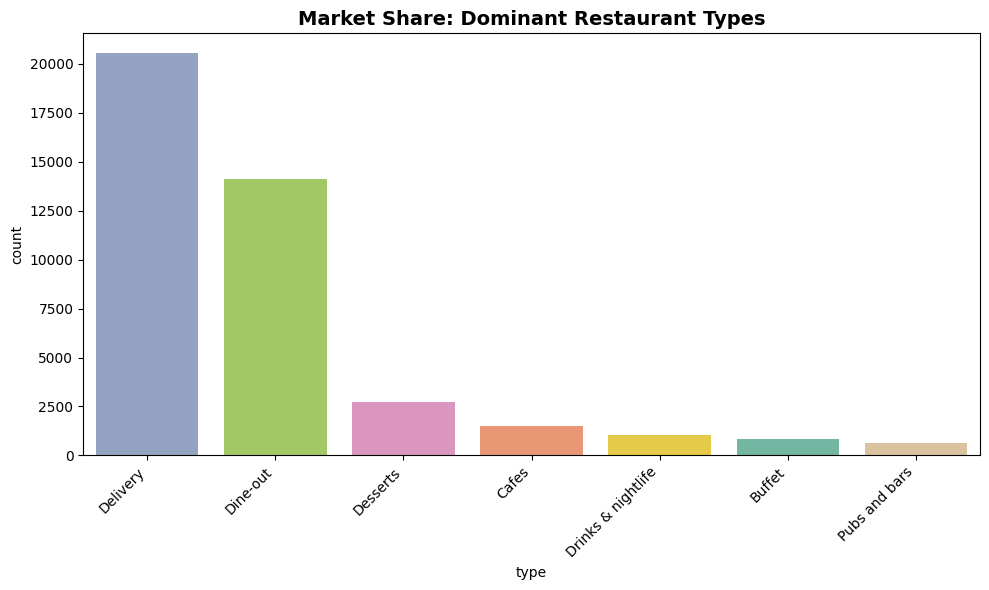

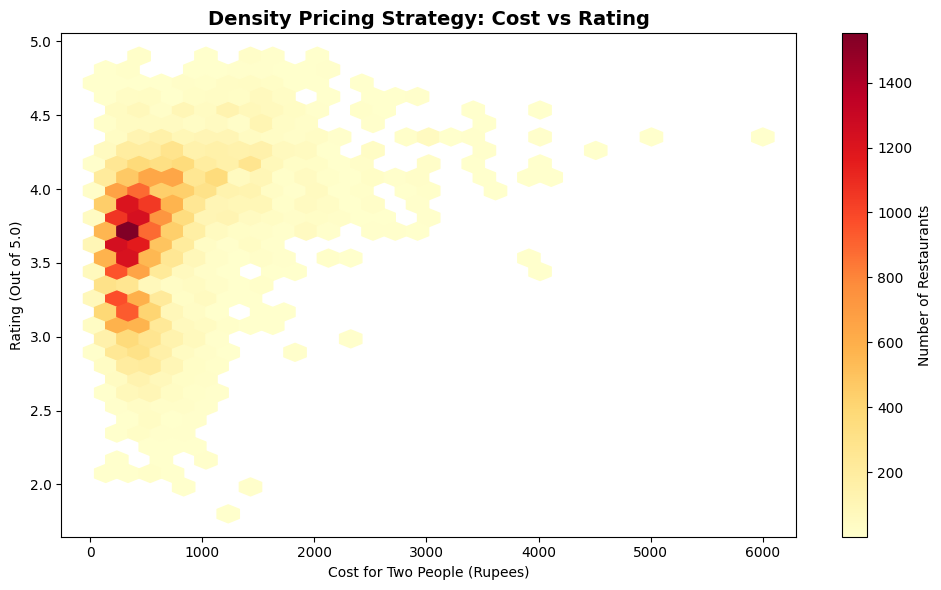

In [27]:
#analysis
#What types of restaurants are dominating the Bangalore market
plt.figure(figsize=(16,6))

plt.figure(figsize=(10,6))
sns.countplot(x='type', data=df, hue='type', palette='Set2', legend=False, order=df['type'].value_counts().index)
plt.title('Market Share: Dominant Restaurant Types', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#Pricing Strategy
plt.figure(figsize=(10, 6))
plt.hexbin(df['cost'], df['rate'], gridsize=30, cmap='YlOrRd', mincnt=1)
plt.colorbar(label='Number of Restaurants')
plt.title('Density Pricing Strategy: Cost vs Rating', fontsize=14, fontweight='bold')
plt.xlabel('Cost for Two People (Rupees)')
plt.ylabel('Rating (Out of 5.0)')
plt.tight_layout()
plt.show()

### The Voting Factor & Correlation
**Question:** Does price actually drive ratings, or is there a hidden variable?

We are running a correlation matrix across Rating, Cost, and Votes. A restaurant with a 4.5 rating and 5 votes is essentially meaningless compared to a 4.5 rating with 5,000 votes. We need to see mathematically which variable actually drives customer satisfaction.

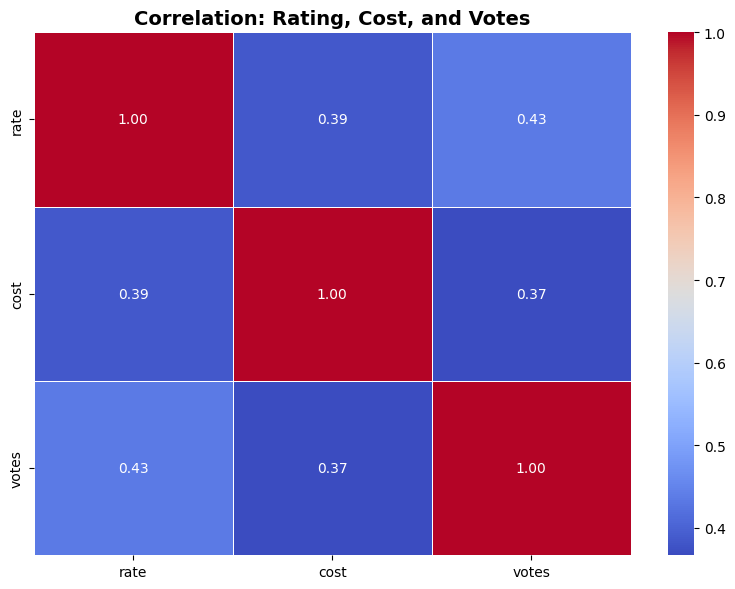

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
correlation_matrix = df[['rate', 'cost', 'votes']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation: Rating, Cost, and Votes', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Service Impact: Online Delivery & Table Booking
**Question:** Does offering modern conveniences like online ordering or table reservations actually boost a restaurant's average rating?

We will compare the average ratings of restaurants that offer these services versus those that do not.

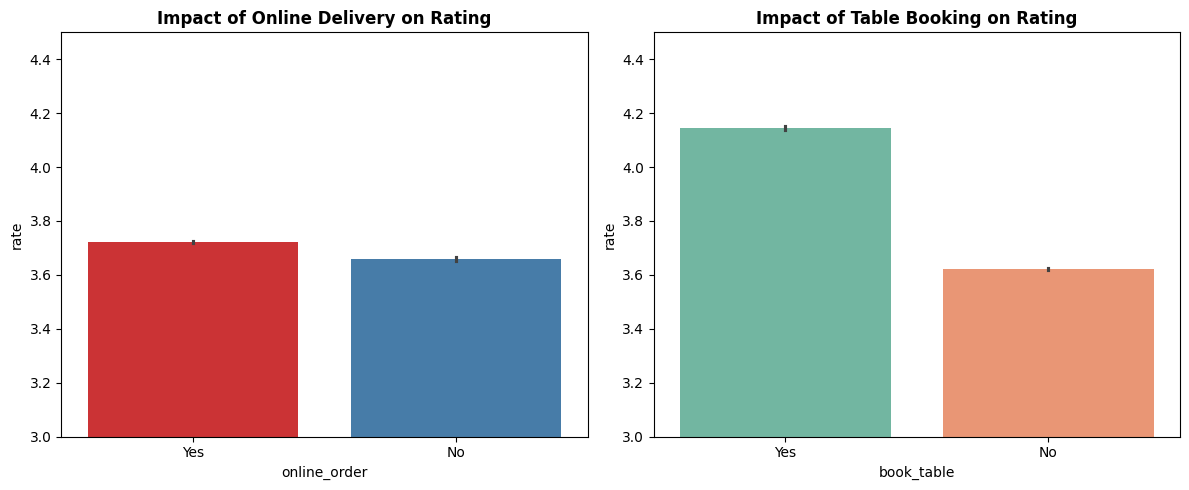

In [29]:
plt.figure(figsize=(12, 5))

# Online Order Subplot
plt.subplot(1, 2, 1)
sns.barplot(x='online_order', y='rate', data=df, hue='online_order', palette='Set1', legend=False)
plt.title('Impact of Online Delivery on Rating', fontweight='bold')
plt.ylim(3.0, 4.5) # Zooming in to see the difference clearly

# Table Booking Subplot
plt.subplot(1, 2, 2)
sns.barplot(x='book_table', y='rate', data=df, hue='book_table', palette='Set2', legend=False)
plt.title('Impact of Table Booking on Rating', fontweight='bold')
plt.ylim(3.0, 4.5)

plt.tight_layout()
plt.show()

## 4. Geospatial Saturation: Where NOT to open
**Question:** Which localities have the most brutal competition?

Finding a location is the most important part of opening a restaurant. We will group the data by neighborhood to see exactly where the market is most crowded. Spoiler: BTM Layout and Koramangala are going to be packed.

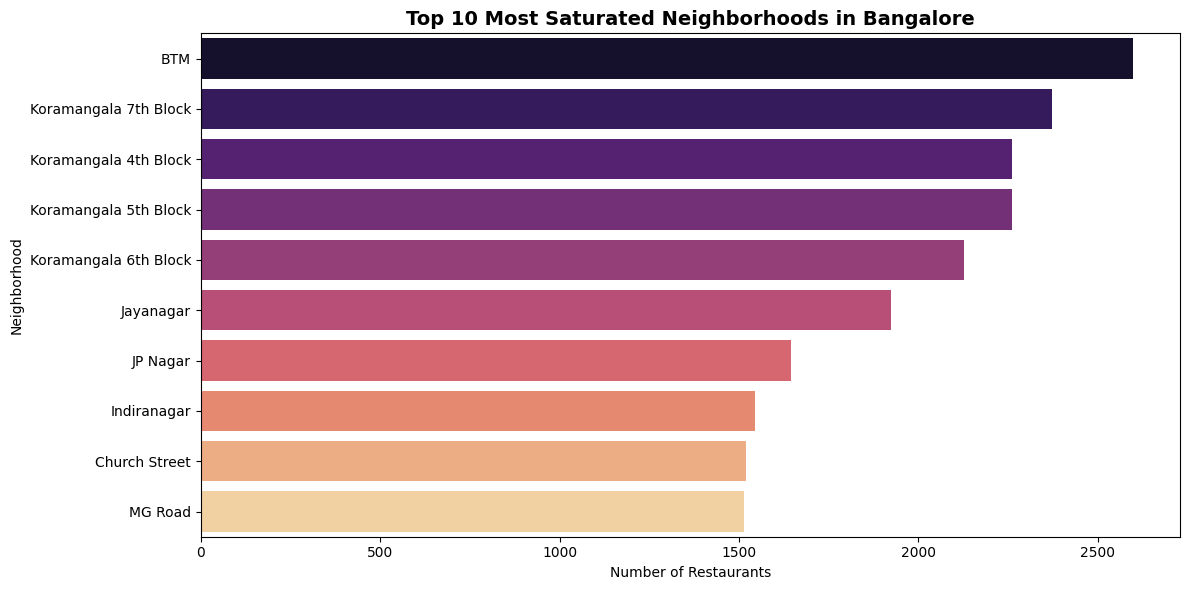

In [30]:
#where to open a new restaurant
# top 10 neighborhoods 
top_locations = df['city'].value_counts().head(10)
plt.figure(figsize=(12, 6))
sns.barplot(x=top_locations.values, y=top_locations.index, hue=top_locations.index, palette='magma', legend=False)
plt.title('Top 10 Most Saturated Neighborhoods in Bangalore', fontsize=14, fontweight='bold')
plt.xlabel('Number of Restaurants')
plt.ylabel('Neighborhood')
plt.tight_layout()
plt.show()

## 5. Competitor Analysis: The BTM Premium Market
**Question:** If we open a premium restaurant in the most crowded neighborhood, who are our direct competitors?

Let's zoom specifically into BTM Layout and filter for only the premium dining spots (Cost > 1000 Rupees). This generates the exact kind of competitive landscape table you would hand to a business stakeholder.

In [31]:
# BTM Premium Competitors
btm_premium = df[(df['location'] == 'BTM') & (df['cost'] > 1000)]
top_premium_btm = btm_premium.sort_values(by=['rate', 'votes'], ascending=[False, False])

# Displaying the stakeholder-ready table with votes included
top_premium_btm[['name', 'rate', 'votes', 'cost', 'type']].head(10)

,name,rate,votes,cost,type
37099,AB's - Absolute Barbecues,4.9,6490,1600.0,Dine-out
21279,AB's - Absolute Barbecues,4.9,6452,1600.0,Dine-out
19393,AB's - Absolute Barbecues,4.9,6404,1600.0,Buffet
21770,AB's - Absolute Barbecues,4.9,6404,1600.0,Buffet
23587,AB's - Absolute Barbecues,4.9,6404,1600.0,Dine-out
8260,AB's - Absolute Barbecues,4.9,6375,1600.0,Buffet
10389,AB's - Absolute Barbecues,4.9,6375,1600.0,Dine-out
37649,"3B's - Buddies, Bar & Barbecues",4.4,1181,1100.0,Pubs and bars
37103,"3B's - Buddies, Bar & Barbecues",4.4,1178,1100.0,Dine-out
37590,"3B's - Buddies, Bar & Barbecues",4.4,1178,1100.0,Drinks & nightlife
